正在分析目标列: p_combined
原始行数: 1431, 删除缺失值后: 1377 (删除了 54 行)

--- 基础统计清单 ---
均值 (Mean): 0.3056
中位数 (Median): 0.2504
标准差 (Std): 0.2399
最小值 (Min): 0.0000
最大值 (Max): 0.9949
偏度 (Skewness): 0.6079
峰度 (Kurtosis): -0.7144

--- 异常值检测清单 ---
IQR: 0.3837
正常范围: [-0.4801, 1.0546]
发现异常值数量: 0 (0.00%)

--- 分箱构建结果 ---
level_group
Very Low     276
Low          275
Medium       275
High         275
Very High    276
Name: count, dtype: int64


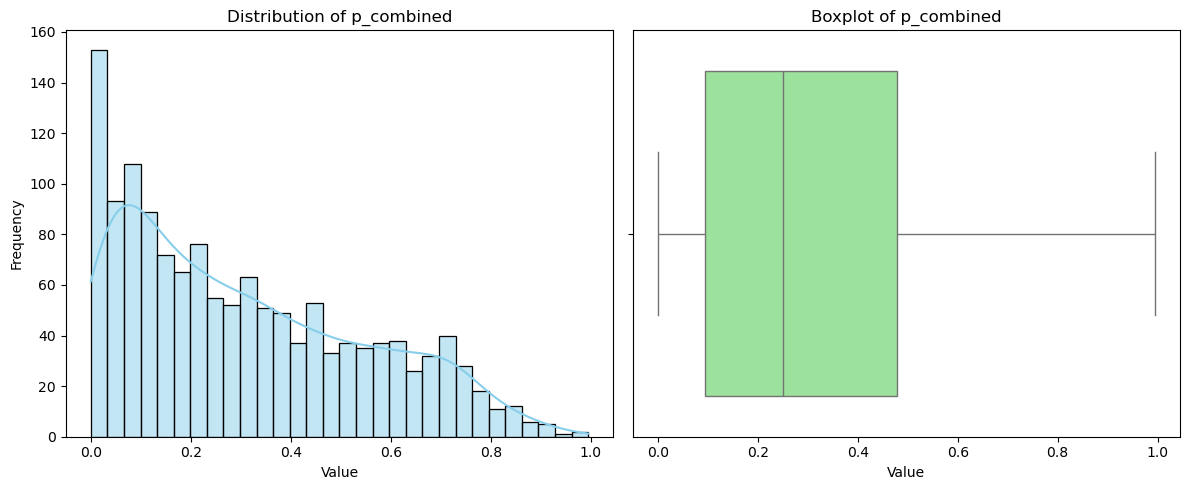

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
file_path = 'combined_results_enhanced.xlsx'
df = pd.read_excel(file_path)

# 自动识别最后一列作为分析目标
target_col = df.columns[-1]
print(f"正在分析目标列: {target_col}")

# 2. 清洗清单：处理缺失值
initial_count = len(df)
# 删除目标列为空的行
df_clean = df.dropna(subset=[target_col]).copy()
cleaned_count = len(df_clean)
print(f"原始行数: {initial_count}, 删除缺失值后: {cleaned_count} (删除了 {initial_count - cleaned_count} 行)")

# 提取纯数据序列
data = df_clean[target_col]

# 3. 体检清单：计算统计量
stats_summary = {
    "均值 (Mean)": data.mean(),
    "中位数 (Median)": data.median(),
    "标准差 (Std)": data.std(),
    "最小值 (Min)": data.min(),
    "最大值 (Max)": data.max(),
    "偏度 (Skewness)": data.skew(), # >0 右偏, <0 左偏
    "峰度 (Kurtosis)": data.kurt()  # >0 尖峰, <0 平峰
}

print("\n--- 基础统计清单 ---")
for k, v in stats_summary.items():
    print(f"{k}: {v:.4f}")

# 4. 质控清单：异常值检测 (IQR法)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]
print("\n--- 异常值检测清单 ---")
print(f"IQR: {IQR:.4f}")
print(f"正常范围: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"发现异常值数量: {len(outliers)} ({len(outliers)/len(data):.2%})")

# 5. 特征构建清单：分箱示例
# 使用等频分箱 (Quantile Cut) 将数据分为5组
df_clean['level_group'] = pd.qcut(data, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
print("\n--- 分箱构建结果 ---")
print(df_clean['level_group'].value_counts().sort_index())

# 6. 可视化验证
plt.figure(figsize=(12, 5))

# 左图：直方图 + 密度曲线
plt.subplot(1, 2, 1)
sns.histplot(data, kde=True, bins=30, color='skyblue')
plt.title(f'Distribution of {target_col}')
plt.xlabel('Value')
plt.ylabel('Frequency')

# 右图：箱线图 (查看离群点)
plt.subplot(1, 2, 2)
sns.boxplot(x=data, color='lightgreen')
plt.title(f'Boxplot of {target_col}')
plt.xlabel('Value')

plt.tight_layout()
plt.show() # 如果在Jupyter中运行，这会直接显示图片

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1. 加载数据
file_path = 'combined_results_enhanced.xlsx'
df = pd.read_excel(file_path)
target_col = df.columns[-1]

# 2. 清洗数据
df_clean = df.dropna(subset=[target_col]).copy()
data = df_clean[[target_col]].values

# ---------------------------------------------------------
# 方法 A: K-Means (Jenks) - 强制分 3 组
# ---------------------------------------------------------
# 训练模型
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(data)

# 排序标签 (保证 1=Low, 2=Medium, 3=High)
centers = kmeans.cluster_centers_.flatten()
sorted_idx = np.argsort(centers)
label_map = {old: new + 1 for new, old in enumerate(sorted_idx)} # +1 为了让标签变成 1,2,3

df_clean['Jenks_Group_3'] = kmeans.predict(data)
df_clean['Jenks_Group_3'] = df_clean['Jenks_Group_3'].map(label_map)

# ---------------------------------------------------------
# 方法 B: Head/Tail Breaks - 截断为 3 组
# ---------------------------------------------------------
# 逻辑：
# 第1刀：整体均值 (Mean1) -> 切分出 "低组 (Tail)"
# 第2刀：头部均值 (Mean2) -> 切分出 "中组 (Head-Tail)" 和 "高组 (Head-Head)"

mean1 = df_clean[target_col].mean()
head_data = df_clean[df_clean[target_col] > mean1][target_col]
mean2 = head_data.mean()

# 定义切分点
# bins = [负无穷, Mean1, Mean2, 正无穷]
bins = [-np.inf, mean1, mean2, np.inf]
labels = ['Low (Tail)', 'Medium (Head-Tail)', 'High (Head-Head)']

df_clean['HeadTail_Group_3'] = pd.cut(df_clean[target_col], bins=bins, labels=labels)

# ---------------------------------------------------------
# 3. 输出结果与统计
# ---------------------------------------------------------
print("--- 方法 A: Jenks (3组) 统计 ---")
print(df_clean.groupby('Jenks_Group_3')[target_col].agg(['min', 'max', 'count', 'mean']))

print("\n--- 方法 B: Head/Tail (3组) 统计 ---")
print(f"切分点: Mean1={mean1:.4f}, Mean2={mean2:.4f}")
print(df_clean.groupby('HeadTail_Group_3')[target_col].agg(['min', 'max', 'count', 'mean']))

# 保存文件
df_clean.to_csv('combined_results_3groups.csv', index=False)
print("\n结果已保存至: combined_results_3groups.csv")

--- 方法 A: Jenks (3组) 统计 ---
                        min       max  count      mean
Jenks_Group_3                                         
1              8.051636e-08  0.221260    630  0.093716
2              2.218739e-01  0.503845    427  0.349392
3              5.077042e-01  0.994925    320  0.664510

--- 方法 B: Head/Tail (3组) 统计 ---
切分点: Mean1=0.3056, Mean2=0.5374
                             min       max  count      mean
HeadTail_Group_3                                           
Low (Tail)          8.051636e-08  0.303810    773  0.124524
Medium (Head-Tail)  3.063215e-01  0.534549    319  0.408211
High (Head-Head)    5.379443e-01  0.994925    285  0.682100

结果已保存至: combined_results_3groups.csv


D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\yhh19\AppData\Local\Temp\ipykernel_444\352492846.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby('HeadTail_Group_3')[target_col].agg(['min', 'max', 'count', 'mean']))


In [8]:
import pandas as pd
import numpy as np

# 1. 加载数据
# 请确保您的文件名正确，如果是 Excel 文件请用 pd.read_excel
file_path = 'combined_results_enhanced.xlsx'
df = pd.read_excel(file_path)

# 自动识别最后一列为目标列
target_col = df.columns[-1]

# 2. 清洗数据：删除缺失值
df_clean = df.dropna(subset=[target_col]).copy()

# ---------------------------------------------------------
# 方法: Head/Tail Breaks - 截断为 3 组 (0, 1, 2)
# ---------------------------------------------------------

# 第一步：计算整体均值 (Mean1)
mean1 = df_clean[target_col].mean()

# 第二步：筛选出头部数据 (> Mean1)，计算头部均值 (Mean2)
head_data = df_clean[df_clean[target_col] > mean1][target_col]
mean2 = head_data.mean()

# 定义切分点 (Bins)
# 0级: (-∞, Mean1]
# 1级: (Mean1, Mean2]
# 2级: (Mean2, +∞)
bins = [-np.inf, mean1, mean2, np.inf]

# 定义等级标签
labels = [0, 1, 2]

# 应用切分
df_clean['HeadTail_Label'] = pd.cut(df_clean[target_col], bins=bins, labels=labels)

# ---------------------------------------------------------
# 3. 输出结果与统计
# ---------------------------------------------------------
print("\n--- Head/Tail Breaks (3组) 统计 ---")
print(f"切分点 1 (Mean1): {mean1:.4f}")
print(f"切分点 2 (Mean2): {mean2:.4f}")
print("-" * 30)
print(df_clean.groupby('HeadTail_Label')[target_col].agg(['min', 'max', 'count', 'mean']))

# 保存为 Excel 文件
output_file = 'combined_results_3groups_HT.xlsx'
df_clean.to_excel(output_file, index=False)
print(f"\n结果已保存至: {output_file}")


--- Head/Tail Breaks (3组) 统计 ---
切分点 1 (Mean1): 0.3056
切分点 2 (Mean2): 0.5374
------------------------------
                         min       max  count      mean
HeadTail_Label                                         
0               8.051636e-08  0.303810    773  0.124524
1               3.063215e-01  0.534549    319  0.408211
2               5.379443e-01  0.994925    285  0.682100


C:\Users\yhh19\AppData\Local\Temp\ipykernel_444\903129172.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby('HeadTail_Label')[target_col].agg(['min', 'max', 'count', 'mean']))



结果已保存至: combined_results_3groups_HT.xlsx
